# El tumor fabrica su propio antioxidante

Los suplementos antioxidantes prometían frenar el cáncer. En los ensayos no solo fallaron: en varios, los resultados empeoraron. Este trabajo ofrece una explicación candidata — en ratones, el tumor ya estaba usando ese truco, y lo usa contra las células que deberían atacarlo.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Tumor-derived antioxidants suppress immunity by depriving T cells of reactive oxygen species* — Wesolowski et al., *Science* (3 de septiembre de 2026)
**DOI:** [10.1126/science.adz8203](https://doi.org/10.1126/science.adz8203)
**Datos:** [Data S1–S6, material suplementario de *Science*](https://www.science.org/doi/suppl/10.1126/science.adz8203/suppl_file/science.adz8203_data_s1_to_s6.zip)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-03-antioxidantes-tumor-celulas-t/notebook.ipynb)

**Video:** [Pendiente]

## Un charco de líquido alrededor del tumor

Un tumor no es solo un montón de células: viene con su propio caldo. Ese líquido que empapa el tejido —el **fluido intersticial**— es lo que respiran las células inmunes cuando entran a atacar.

El equipo exprimió ese fluido de tumores de ratón y lo comparó, proteína por proteína, contra la sangre del mismo animal. Después hizo algo más directo: agarró la proteína que más le llamó la atención, se la echó a células T en cultivo, y midió qué genes dejaban de encenderse.

La pieza que cierra el rompecabezas es rara, y todo apunta a que es así: las células T necesitan **especies reactivas de oxígeno** (los famosos radicales libres) para transmitir la señal de "ataca". Un antioxidante que se los quite no las envenena — las deja mudas.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
PROTEINA_FOCO = 'Prdx1'        # La proteína protagonista del paper
PADJ_UMBRAL = 0.05             # Umbral de significancia estadística
GENES_EFECTORES = ['Ifng', 'Gzmb', 'Prf1', 'Tnf', 'Il2', 'Tnfrsf9', 'Nr4a1']
FUENTE = 'Fuente: Wesolowski et al. (2026), Science | Datos: Data S1-S6 del propio paper'
COLOR_DATOS = '#2563EB'        # Azul CaM — datos principales
COLOR_ALERTA = '#DC2626'       # Rojo — contraste
COLOR_SECUNDARIO = '#059669'   # Verde — serie secundaria
COLOR_REFERENCIA = '#D97706'   # Ámbar — líneas de referencia
COLOR_GRIS = '#BBBBBB'         # Gris — contexto

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats


def eje_es(decimales):
    """Formatea los ticks con coma decimal y signo menos tipográfico."""
    return FuncFormatter(
        lambda v, _: f'{v:.{decimales}f}'.replace('.', ',').replace('-', '\u2212'))


def etiqueta_fc(fc):
    """'211x' si está enriquecida, '45,5x menos' si está depletada."""
    v = fc if fc >= 1 else 1 / fc
    s = f'{v:.0f}' if v >= 100 else f'{v:.1f}'
    if s.endswith('.0'):
        s = s[:-2]
    s = s.replace('.', ',')
    return f'{s}x' if fc >= 1 else f'{s}x menos'

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
SLUG = '2026-09-03-antioxidantes-tumor-celulas-t'

# Estilo editorial CaM (local -> descarga como respaldo)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# Descarga automática de los datos si no están en local
ARCHIVOS = ['proteoma_tif_vs_suero.csv', 'degs_celulas_t.csv',
            'expresion_tif_vs_suero_celulas_t.csv']
os.makedirs('datos', exist_ok=True)
for nombre in ARCHIVOS:
    destino = f'datos/{nombre}'
    if not os.path.exists(destino):
        urllib.request.urlretrieve(f'{BASE}/papers/{SLUG}/datos/{nombre}', destino)

proteoma = pd.read_csv('datos/proteoma_tif_vs_suero.csv')
degs = pd.read_csv('datos/degs_celulas_t.csv')
tif = pd.read_csv('datos/expresion_tif_vs_suero_celulas_t.csv')

# El piso de imputación: cuando una proteína no se detecta en suero, el
# pipeline le asigna el valor mínimo del ensayo. Ese valor se repite y hay
# que contarlo antes de creerse cualquier enriquecimiento.
PISO_SUERO = proteoma['abundancia_suero'].mode()[0]
en_piso = proteoma['abundancia_suero'] == PISO_SUERO

def es(n, dec=0):
    """Número en formato español: punto de miles, coma decimal."""
    return f'{n:,.{dec}f}'.replace(',', '@').replace('.', ',').replace('@', '.')


print(f'Proteoma del fluido tumoral: {len(proteoma)} proteínas')
print(f'  Piso de detección en sangre: {es(PISO_SUERO, 2)}')
print(f'  Proteínas ancladas a ese piso: {en_piso.sum()} '
      f'({en_piso.mean() * 100:.1f}%)  <- {PROTEINA_FOCO} es una de ellas: '
      f'{"sí" if en_piso[proteoma.gen == PROTEINA_FOCO].iloc[0] else "no"}')
print(f'  Enriquecidas en el tumor (log2FC > 0): '
      f'{(proteoma.log2fc_tif_vs_suero > 0).sum()} '
      f'({(proteoma.log2fc_tif_vs_suero > 0).mean() * 100:.1f}%)')
print(f'  Mediana log2FC: {proteoma.log2fc_tif_vs_suero.median():.2f}  '
      f'(IQR {proteoma.log2fc_tif_vs_suero.quantile(.25):.2f}'
      f'-{proteoma.log2fc_tif_vs_suero.quantile(.75):.2f})')
print()
print(f'RNA-seq de células T CD8+: {degs.comparacion.nunique()} comparaciones, '
      f'{es(len(degs))} filas')
for comp in ['PRDX1_estimulado', 'PRDX1_sin_estimulo', 'NAC_estimulado']:
    sub = degs[degs.comparacion == comp]
    sig = (sub.padj < PADJ_UMBRAL).sum()
    print(f'  {comp:<20} n={len(sub):>6}  significativos={sig:>5} '
          f'({sig / len(sub) * 100:>4.1f}%)  sd(log2FC)={sub.log2fc.std():.3f}')
print()
print(f'Fluido tumoral completo sobre células T: {es(len(tif))} genes diferenciales')

Proteoma del fluido tumoral: 490 proteínas
  Piso de detección en sangre: 206.244,53
  Proteínas ancladas a ese piso: 373 (76.1%)  <- Prdx1 es una de ellas: sí
  Enriquecidas en el tumor (log2FC > 0): 402 (82.0%)
  Mediana log2FC: 3.89  (IQR 1.95-5.38)

RNA-seq de células T CD8+: 4 comparaciones, 49.214 filas
  PRDX1_estimulado     n= 11935  significativos= 3817 (32.0%)  sd(log2FC)=0.144
  PRDX1_sin_estimulo   n= 11935  significativos= 2757 (23.1%)  sd(log2FC)=0.108
  NAC_estimulado       n= 12672  significativos= 9408 (74.2%)  sd(log2FC)=0.825

Fluido tumoral completo sobre células T: 3.827 genes diferenciales


Aquí está.

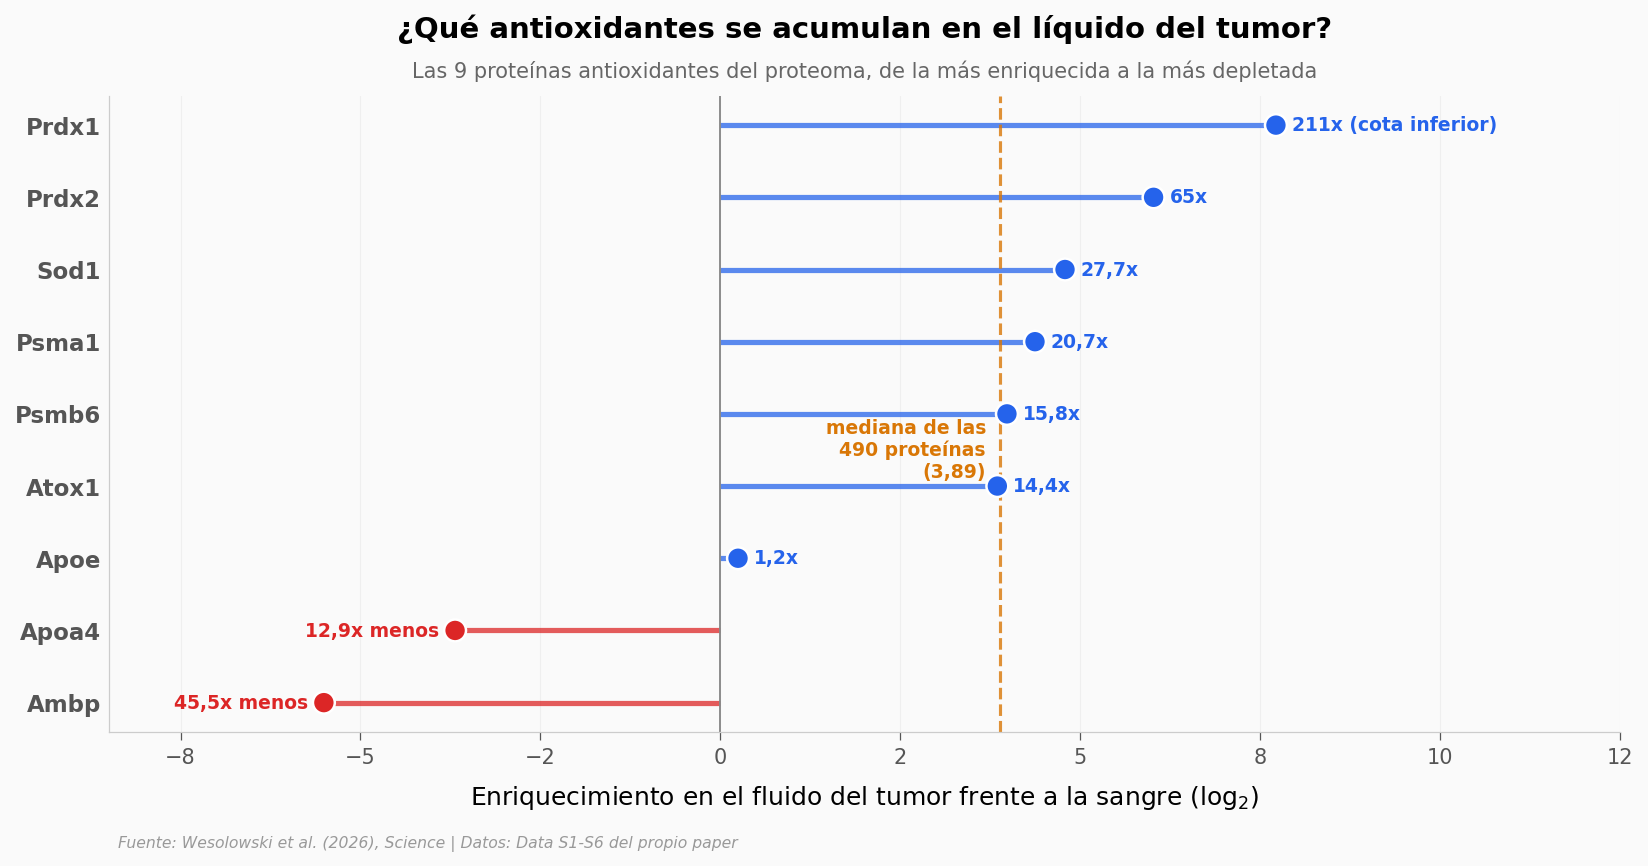

Mediana de los 9 antioxidantes: 3.98
Mediana del resto del proteoma: 3.89
Mann-Whitney U=2116, p=0.909 (n=9 antioxidantes)


In [2]:
# Los 9 antioxidantes anotados del proteoma, ordenados por enriquecimiento.
# La línea ámbar es la mediana de las 490 proteínas: el listón contra el que
# hay que leer cualquier "está enriquecida".
aox = (proteoma[proteoma.es_antioxidante == 'Si']
       .sort_values('log2fc_tif_vs_suero'))
mediana_proteoma = proteoma.log2fc_tif_vs_suero.median()

fig, ax = plt.subplots(figsize=(13, 5.5))
colores = [COLOR_DATOS if v > 0 else COLOR_ALERTA
           for v in aox.log2fc_tif_vs_suero]
y = np.arange(len(aox))

ax.hlines(y, 0, aox.log2fc_tif_vs_suero, color=colores, linewidth=2.5, alpha=0.75)
ax.scatter(aox.log2fc_tif_vs_suero, y, color=colores, s=110,
           edgecolors='white', linewidths=1.2, zorder=5)

ax.axvline(0, color='#888888', linewidth=0.9)
ax.axvline(mediana_proteoma, color=COLOR_REFERENCIA, linewidth=1.5,
           linestyle='--', alpha=0.8)
ax.text(mediana_proteoma - 0.2, 3.5,
        f'mediana de las\n490 proteínas\n({mediana_proteoma:.2f})'.replace('.', ','),
        fontsize=9, color=COLOR_REFERENCIA, fontweight='bold',
        va='center', ha='right')

for i, (gen, v, fc) in enumerate(zip(aox.gen, aox.log2fc_tif_vs_suero,
                                     aox.foldchange_tif_vs_suero)):
    etiqueta = etiqueta_fc(fc)
    if gen == PROTEINA_FOCO:
        etiqueta += ' (cota inferior)'
    offset = 0.22 if v > 0 else -0.22
    ax.text(v + offset, i, etiqueta, fontsize=9, va='center',
            ha='left' if v > 0 else 'right', color=colores[i], fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(aox.gen, fontsize=11, fontweight='bold')
ax.set_xlabel('Enriquecimiento en el fluido del tumor frente a la sangre (log$_2$)')
ax.set_xlim(-8.5, 12.5)
ax.xaxis.set_major_formatter(eje_es(0))
ax.set_title('¿Qué antioxidantes se acumulan en el líquido del tumor?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Las 9 proteínas antioxidantes del proteoma, de la más enriquecida a la más depletada',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.grid(axis='x', alpha=0.4)
ax.grid(axis='y', visible=False)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/antioxidantes_enriquecimiento.png', dpi=200, bbox_inches='tight')
plt.show()

u, p_aox = stats.mannwhitneyu(aox.log2fc_tif_vs_suero,
                              proteoma[proteoma.es_antioxidante == 'No'].log2fc_tif_vs_suero)
print(f'Mediana de los 9 antioxidantes: {aox.log2fc_tif_vs_suero.median():.2f}')
print(f'Mediana del resto del proteoma: '
      f'{proteoma[proteoma.es_antioxidante == "No"].log2fc_tif_vs_suero.median():.2f}')
print(f'Mann-Whitney U={u:.0f}, p={p_aox:.3f} (n=9 antioxidantes)')

## Lo que se ve, y lo que no

PRDX1 —peroxirredoxina 1, una enzima que desactiva peróxido de hidrógeno— aparece **211 veces más concentrada** en el fluido del tumor que en la sangre. PRDX2 la sigue con 65x y la superóxido dismutasa SOD1 con 27,7x. Hasta ahí, la historia del paper.

Ahora lo incómodo, que son tres cosas:

**Ese 211x es un piso, no una medida.** 373 de las 490 proteínas (el 76,1%) comparten exactamente el mismo valor en sangre: es el mínimo que el detector puede reportar cuando no encuentra nada. PRDX1 es una de ellas. Su enriquecimiento real puede ser mayor; lo que sabemos es que es **al menos** 211x.

**El 82% de proteínas "enriquecidas en el tumor" es en buena parte un artefacto de ese mismo piso.** Si nos quedamos solo con las 117 proteínas que sí se midieron de verdad en ambos líquidos, únicamente el 25,6% está enriquecida y la mediana se da vuelta a −3,06. No hay que leer ese 82% como biología.

**Y "los antioxidantes" no son el hallazgo.** Como clase, los 9 anotados no se distinguen del resto del proteoma: mediana 3,98 contra 3,89, con Mann-Whitney p = 0,909 y Cohen's d = −0,12 (despreciable). Dos de ellos están *depletados* (Apoa4 y Ambp, las dos barras rojas). El hallazgo es sobre PRDX1 y PRDX2 en concreto — que es exactamente lo que el paper afirma, ni más.

## El detalle que convierte la correlación en efecto

Que una enzima se acumule en el tumor no dice nada por sí solo sobre lo que hace. El segundo experimento sí lo pone a prueba: añadir PRDX1 recombinante a células T CD8+ en cultivo y ver qué genes cambian.

Y ahí está la clave. El equipo midió las mismas células en dos estados: **en reposo** y **estimuladas** vía el receptor de la célula T, que es como decir "ya viste al enemigo, actúa".

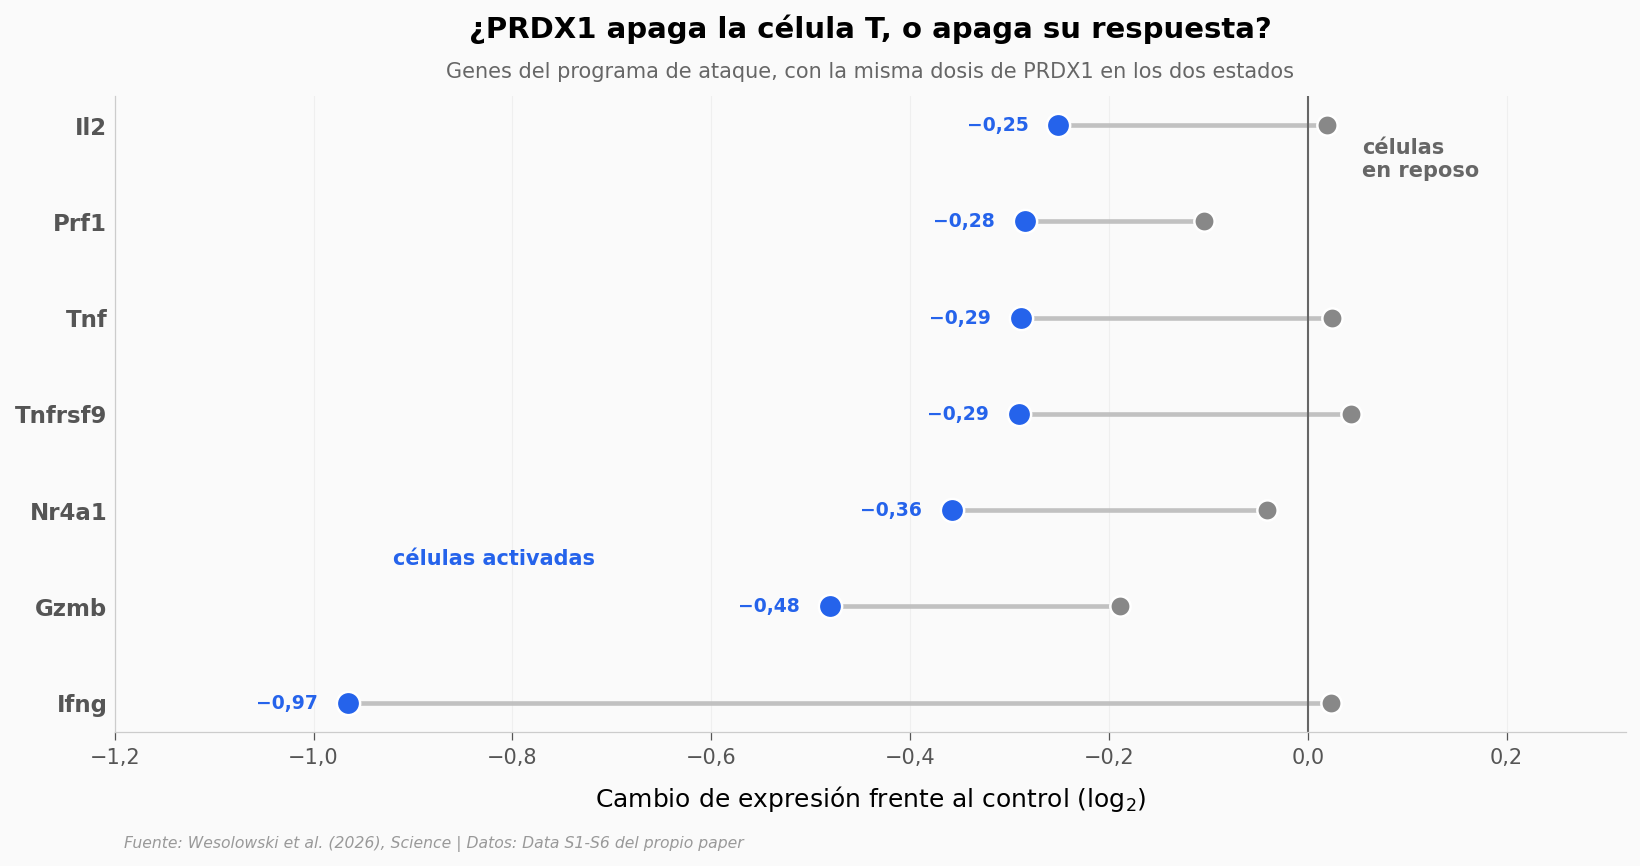

Media del cambio, células activadas: -0.417 log2
Media del cambio, células en reposo: -0.032 log2
Significativos (padj < 0.05): 7/7 activadas, 1/7 en reposo
Wilcoxon pareado (n=7 genes): W=0, p=0.0156, d pareado=-1.42
Ifng activadas: -0.966 (padj=6.5e-09)  |  en reposo: +0.023 (padj=0.79)


In [3]:
# El corazón del mecanismo: el mismo tratamiento (PRDX1 recombinante) sobre
# las mismas células, con y sin la señal de activación.
pe = degs[degs.comparacion == 'PRDX1_estimulado'].set_index('gen')
ps = degs[degs.comparacion == 'PRDX1_sin_estimulo'].set_index('gen')

orden = pe.loc[GENES_EFECTORES, 'log2fc'].sort_values().index.tolist()
con = pe.loc[orden, 'log2fc'].values
sin_ = ps.loc[orden, 'log2fc'].values
y = np.arange(len(orden))

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.hlines(y, sin_, con, color=COLOR_GRIS, linewidth=2.2, alpha=0.9, zorder=2)
ax.scatter(sin_, y, color='#888888', s=95, edgecolors='white',
           linewidths=1.2, zorder=5)
ax.scatter(con, y, color=COLOR_DATOS, s=125, edgecolors='white',
           linewidths=1.2, zorder=6)
ax.axvline(0, color='#666666', linewidth=1.0)

# Etiquetas inline en lugar de caja de leyenda
ax.text(0.055, len(orden) - 1.35, 'células\nen reposo', fontsize=10,
        color='#666666', fontweight='bold', ha='left', va='center')
ax.text(-0.92, 1.5, 'células activadas', fontsize=10,
        color=COLOR_DATOS, fontweight='bold', ha='left', va='center')

for i, gen in enumerate(orden):
    ax.text(con[i] - 0.03, i,
            f'{con[i]:+.2f}'.replace('.', ',').replace('-', '\u2212'),
            fontsize=9, va='center', ha='right', color=COLOR_DATOS,
            fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(orden, fontsize=11, fontweight='bold')
ax.set_xlabel('Cambio de expresión frente al control (log$_2$)')
ax.set_xlim(-1.20, 0.32)
ax.xaxis.set_major_formatter(eje_es(1))
ax.set_title('¿PRDX1 apaga la célula T, o apaga su respuesta?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Genes del programa de ataque, con la misma dosis de PRDX1 en los dos estados',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.grid(axis='x', alpha=0.4)
ax.grid(axis='y', visible=False)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/efecto_condicional.png', dpi=200, bbox_inches='tight')
plt.show()

w, p_w = stats.wilcoxon(con, sin_)
dif = con - sin_
d_pareado = dif.mean() / dif.std(ddof=1)
sig_con = (pe.loc[orden, 'padj'] < PADJ_UMBRAL).sum()
sig_sin = (ps.loc[orden, 'padj'] < PADJ_UMBRAL).sum()
print(f'Media del cambio, células activadas: {con.mean():+.3f} log2')
print(f'Media del cambio, células en reposo: {sin_.mean():+.3f} log2')
print(f'Significativos (padj < {PADJ_UMBRAL}): {sig_con}/7 activadas, '
      f'{sig_sin}/7 en reposo')
print(f'Wilcoxon pareado (n=7 genes): W={w:.0f}, p={p_w:.4f}, '
      f"d pareado={d_pareado:.2f}")
print(f'Ifng activadas: {pe.loc["Ifng", "log2fc"]:+.3f} '
      f'(padj={pe.loc["Ifng", "padj"]:.1e})  |  en reposo: '
      f'{ps.loc["Ifng", "log2fc"]:+.3f} (padj={ps.loc["Ifng", "padj"]:.2f})')

## Un antioxidante fino contra un antioxidante a lo bruto

En el mismo experimento hay un control que vale por sí solo: la **N-acetilcisteína** (NAC), el antioxidante químico de toda la vida, a 60 mM. Sirve para comprobar que quitar radicales libres apaga a la célula T.

Pero comparar sus magnitudes sería trampa, y vale la pena ver por qué.

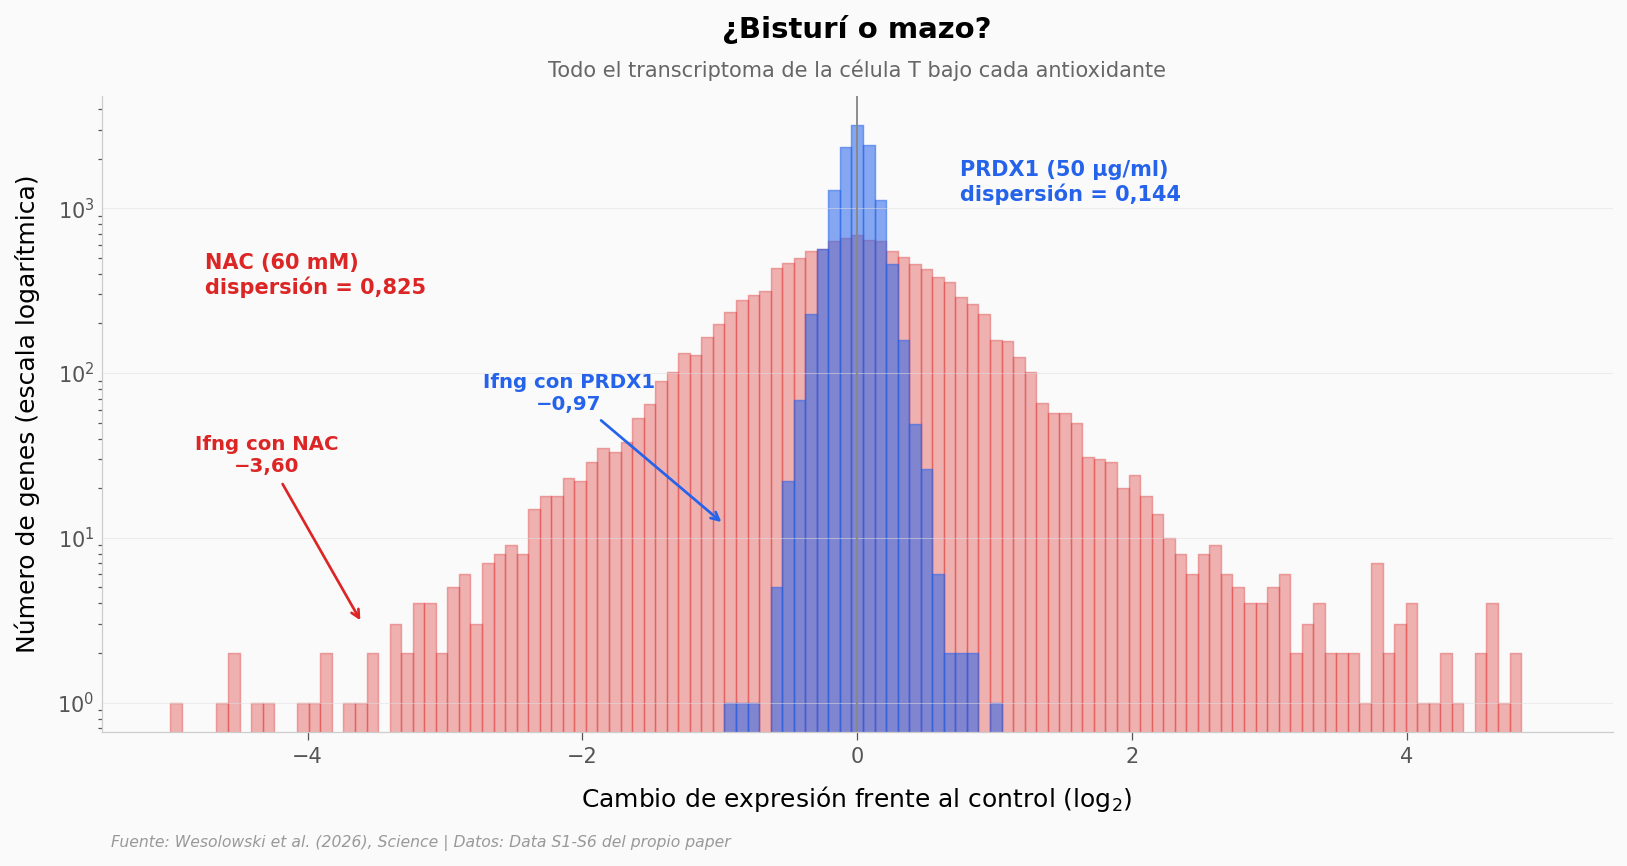

PRDX1  n= 11935 genes | movidos  3817 (32.0%) | sd=0.144 | efecto máximo |log2FC|=1.04
NAC    n= 12672 genes | movidos  9408 (74.2%) | sd=0.825 | efecto máximo |log2FC|=6.86

La dispersión de NAC es 5.7 veces la de PRDX1.


In [4]:
# Dos antioxidantes, dos escalas distintas. Ojo al eje: es el mismo rango
# para los dos, y ahí está toda la historia.
prdx1_e = degs[degs.comparacion == 'PRDX1_estimulado']
nac_e = degs[degs.comparacion == 'NAC_estimulado']

fig, ax = plt.subplots(figsize=(13, 5.5))
bins = np.linspace(-5, 5, 120)
ax.hist(nac_e.log2fc, bins=bins, color=COLOR_ALERTA, alpha=0.35,
        edgecolor=COLOR_ALERTA, linewidth=0.7, label='NAC')
ax.hist(prdx1_e.log2fc, bins=bins, color=COLOR_DATOS, alpha=0.55,
        edgecolor=COLOR_DATOS, linewidth=0.7, label='PRDX1')
ax.set_yscale('log')
ax.axvline(0, color='#888888', linewidth=0.9)

ax.text(0.75, 1100,
        f'PRDX1 (50 µg/ml)\ndispersión = {prdx1_e.log2fc.std():.3f}'.replace('.', ','),
        fontsize=10, color=COLOR_DATOS, fontweight='bold')
ax.text(-4.75, 300,
        f'NAC (60 mM)\ndispersión = {nac_e.log2fc.std():.3f}'.replace('.', ','),
        fontsize=10, color=COLOR_ALERTA, fontweight='bold')
ax.xaxis.set_major_formatter(eje_es(0))

ifng_p = prdx1_e[prdx1_e.gen == 'Ifng'].log2fc.iloc[0]
ifng_n = nac_e[nac_e.gen == 'Ifng'].log2fc.iloc[0]
ax.annotate('Ifng con PRDX1\n−0,97', xy=(ifng_p, 12), xytext=(-2.1, 60),
            fontsize=9.5, color=COLOR_DATOS, fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.3))
ax.annotate('Ifng con NAC\n−3,60', xy=(ifng_n, 3), xytext=(-4.3, 25),
            fontsize=9.5, color=COLOR_ALERTA, fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.3))

ax.set_xlabel('Cambio de expresión frente al control (log$_2$)')
ax.set_ylabel('Número de genes (escala logarítmica)')
ax.set_title('¿Bisturí o mazo?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Todo el transcriptoma de la célula T bajo cada antioxidante',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/prdx1_vs_nac.png', dpi=200, bbox_inches='tight')
plt.show()

for etiqueta, sub in [('PRDX1', prdx1_e), ('NAC', nac_e)]:
    sig = (sub.padj < PADJ_UMBRAL).sum()
    print(f'{etiqueta:<6} n={len(sub):>6} genes | movidos {sig:>5} '
          f'({sig / len(sub) * 100:.1f}%) | sd={sub.log2fc.std():.3f} | '
          f'efecto máximo |log2FC|={sub.log2fc.abs().max():.2f}')
print(f'\nLa dispersión de NAC es {nac_e.log2fc.std() / prdx1_e.log2fc.std():.1f} '
      f'veces la de PRDX1.')

## ¿Qué tan raro es un 211x?

Volvamos a la pregunta de entrada. Sabemos que PRDX1 está muy concentrada en el fluido del tumor. Pero "muy" no es un número hasta que la pongamos contra el resto del proteoma.

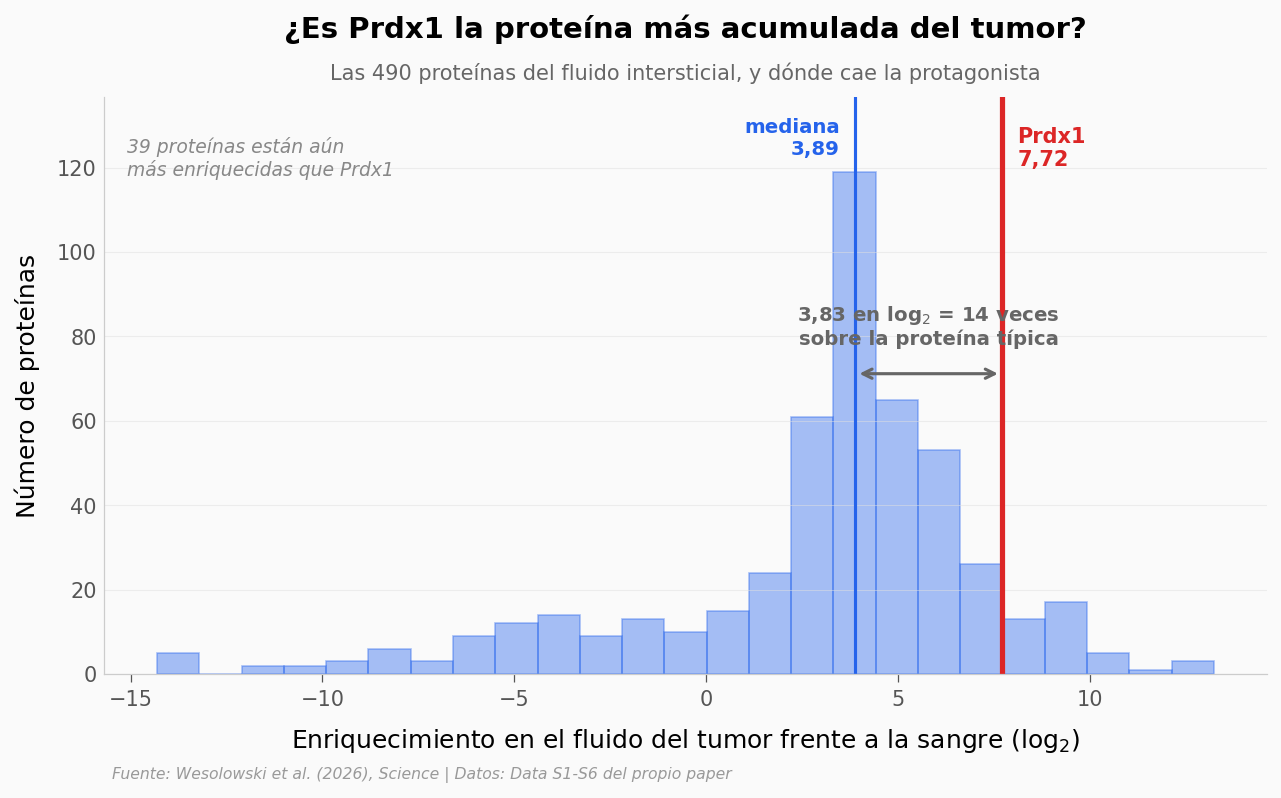

Prdx1: log2FC = 7.72 -> puesto 40 de 490 (percentil 91.8)
Por encima, las 3 más enriquecidas del fluido:
  Ubc      log2FC = 13.24
  Copa     log2FC = 12.84
  Cct3     log2FC = 12.49


In [5]:
# ¿Dónde cae PRDX1 dentro de la distribución completa del proteoma?
lfc = proteoma.log2fc_tif_vs_suero
prdx1_lfc = proteoma.loc[proteoma.gen == PROTEINA_FOCO,
                         'log2fc_tif_vs_suero'].iloc[0]
mediana = lfc.median()

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, _ = ax.hist(lfc, bins=25, color=COLOR_DATOS, alpha=0.4,
                     edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

ax.axvline(mediana, color=COLOR_DATOS, linewidth=1.5)
ax.axvline(prdx1_lfc, color=COLOR_ALERTA, linewidth=2.5)
ax.annotate('', xy=(prdx1_lfc, y_max * 0.52), xytext=(mediana, y_max * 0.52),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((mediana + prdx1_lfc) / 2, y_max * 0.57,
        f'{prdx1_lfc - mediana:.2f} en log$_2$ = 14 veces\nsobre la proteína típica'
        .replace('.', ','),
        fontsize=9.5, color='#666666', ha='center', fontweight='bold')
ax.text(mediana - 0.4, y_max * 0.9, f'mediana\n{mediana:.2f}'.replace('.', ','),
        fontsize=9.5, color=COLOR_DATOS, ha='right', fontweight='bold')
ax.text(prdx1_lfc + 0.4, y_max * 0.88, f'{PROTEINA_FOCO}\n{prdx1_lfc:.2f}'
        .replace('.', ','),
        fontsize=10, color=COLOR_ALERTA, ha='left', fontweight='bold')

por_encima = int((lfc > prdx1_lfc).sum())
ax.text(0.02, 0.93,
        f'{por_encima} proteínas están aún\nmás enriquecidas que {PROTEINA_FOCO}',
        transform=ax.transAxes, fontsize=9, color='#888888',
        ha='left', va='top', style='italic')

ax.set_xlabel('Enriquecimiento en el fluido del tumor frente a la sangre (log$_2$)')
ax.set_ylabel('Número de proteínas')
ax.xaxis.set_major_formatter(eje_es(0))
ax.set_title(f'¿Es {PROTEINA_FOCO} la proteína más acumulada del tumor?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Las 490 proteínas del fluido intersticial, y dónde cae la protagonista',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_proteoma.png', dpi=200, bbox_inches='tight')
plt.show()

rango = int((lfc > prdx1_lfc).sum()) + 1
print(f'{PROTEINA_FOCO}: log2FC = {prdx1_lfc:.2f} -> puesto {rango} de {len(lfc)} '
      f'(percentil {(1 - rango / len(lfc)) * 100:.1f})')
print('Por encima, las 3 más enriquecidas del fluido:')
for _, fila in proteoma.nlargest(3, 'log2fc_tif_vs_suero').iterrows():
    print(f'  {fila.gen:<8} log2FC = {fila.log2fc_tif_vs_suero:.2f}')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| PRDX1 se acumula en el fluido del tumor | ✅ | log2FC = 7,72 → 211x, puesto 40 de 490 (percentil 92). **Cota inferior**: su valor en sangre es el piso de detección |
| PRDX1 es el antioxidante más enriquecido del fluido | ✅ | De los 9 anotados, es el primero: 211x contra 65x de PRDX2 y 27,7x de SOD1 |
| PRDX1 es la proteína más enriquecida del fluido | ❌ | Falso: 39 proteínas están por encima (Ubc 13,24; Copa 12,84; Cct3 12,49 en log₂) |
| "Los antioxidantes" se acumulan como clase | ❌ | Los 9 anotados no se distinguen del resto: mediana 3,98 vs 3,89, Mann-Whitney p = 0,909, n = 9 sin poder estadístico. Dos están depletados |
| El 82% del proteoma está enriquecido en el tumor | ⚠️ | Cierto en el archivo, engañoso como biología: 373/490 proteínas (76,1%) están ancladas al piso de detección en sangre. Entre las 117 medidas de verdad en ambos fluidos, solo el 25,6% está enriquecida y la mediana es −3,06 |
| PRDX1 frena el programa de ataque de la célula T | ✅ | Los 7 genes efectores bajan con estímulo (7/7 con padj < 0,05). Ifng −0,97 (padj = 6,5 × 10⁻⁹), Gzmb −0,48, Prf1 −0,29 |
| El efecto depende de que la célula esté activada | ✅ | Media −0,417 activadas contra −0,032 en reposo; 7/7 significativos contra 1/7. Wilcoxon pareado W = 0, p = 0,016, d pareado = −1,42 (grande), n = 7 genes |
| PRDX1 apaga a la célula T por completo | ❌ | Su efecto máximo en todo el transcriptoma es \|log2FC\| = 1,04 — apenas 2,1 veces, y en un solo gen (*Col11a2*) — con sd = 0,144. Es selectivo, no masivo. Con 11.935 genes hay significancia con efectos mínimos |
| NAC y PRDX1 hacen lo mismo con distinta fuerza | ⚠️ | Son escalas incomparables: NAC a 60 mM mueve el 74,2% del transcriptoma (sd 0,825), PRDX1 a 50 µg/ml el 32,0% (sd 0,144), 5,7 veces menos dispersión. NAC es contraste conceptual, no la misma intervención |
| El fluido tumoral completo hace más que PRDX1 sola | ⚠️ | Ifng cae −2,23 a las 2 h con el fluido entero (medido contra suero) frente a −0,97 con PRDX1 aislada (medida contra su propio control); Il2 llega a −4,59. Son dos experimentos con comparadores distintos: la dirección apunta a que PRDX1 es una pieza y no todo el efecto, pero las magnitudes no se restan entre sí |
| Esto sirve como tratamiento contra el cáncer | ❌ | El paper cierra con *"potentially amenable to therapeutic intervention"*: lo enmarca como posibilidad, no como resultado clínico. Nada aquí se ha probado en personas |

> **Limitaciones.**
> - **Especie: ratón.** Símbolos génicos murinos, UniProt `_MOUSE`. Nada de esto se puede trasladar a pacientes. El paper reanaliza aparte datos humanos, pero eso no está en estos archivos.
> - **El piso de imputación gobierna el proteoma.** Tres de cada cuatro proteínas comparten el mismo valor en sangre. Todos los enriquecimientos que involucran ese piso —PRDX1 incluida— son cotas inferiores.
> - **La clase "antioxidante" tiene n = 9.** Cualquier test sobre ese grupo carece de poder estadístico; el p = 0,909 dice "no distinguimos", no "son iguales".
> - **PRDX1 en reposo no es cero.** Aunque 6 de los 7 genes efectores no se mueven sin estímulo —*Gzmb* sí baja, −0,19 (padj = 0,004)—, 2.757 genes (23,1%) sí cambian con padj < 0,05. El efecto condicional está bien soportado para el programa de ataque, no para el transcriptoma entero.
> - **El RNA no es la proteína.** Estos datos miden expresión génica. Que baje el mensajero de *Ifng* no equivale a medir interferón secretado — eso el paper lo hace con otras técnicas que no están en estos archivos.
> - **Cuatro réplicas por condición según los métodos del paper**, con los cambios ya agregados por DESeq2. Los archivos no traen columna de réplica, así que ese número no se puede verificar aquí ni inspeccionar la consistencia réplica a réplica.

## Ahora tú

**1. ¿Cuánto del "82% enriquecido" sobrevive si quitamos el piso?**
Filtra `proteoma[proteoma.abundancia_suero != PISO_SUERO]` y vuelve a calcular el porcentaje y la mediana. La celda de abajo lo hace; prueba también con el subconjunto contrario.

**2. ¿El efecto condicional aguanta fuera de los 7 genes efectores?**
Cambia `GENES_EFECTORES` en la celda de configuración por otros genes —`Il2ra`, `Cd69`, `Pdcd1`, `Tbx21`— y vuelve a correr la gráfica de la brecha. ¿Sigue apareciendo la separación entre activadas y en reposo?

**3. ¿Qué genes mueve NAC que PRDX1 no toca?**
Cruza las dos comparaciones por gen y quédate con los que son significativos en NAC pero no en PRDX1. ¿Se parecen a un programa concreto, o es ruido a lo ancho?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿qué queda del enriquecimiento cuando quitamos las proteínas
# ancladas al piso de detección?

medidas = proteoma[proteoma.abundancia_suero != PISO_SUERO]
imputadas = proteoma[proteoma.abundancia_suero == PISO_SUERO]

print('TODAS LAS PROTEÍNAS')
print(f'  n = {len(proteoma)} | enriquecidas = '
      f'{(proteoma.log2fc_tif_vs_suero > 0).mean() * 100:.1f}% | '
      f'mediana log2FC = {proteoma.log2fc_tif_vs_suero.median():+.2f}')
print()
print('SOLO LAS MEDIDAS DE VERDAD EN AMBOS FLUIDOS')
print(f'  n = {len(medidas)} | enriquecidas = '
      f'{(medidas.log2fc_tif_vs_suero > 0).mean() * 100:.1f}% | '
      f'mediana log2FC = {medidas.log2fc_tif_vs_suero.median():+.2f}')
print()
print('SOLO LAS ANCLADAS AL PISO (no detectadas en sangre)')
print(f'  n = {len(imputadas)} | enriquecidas = '
      f'{(imputadas.log2fc_tif_vs_suero > 0).mean() * 100:.1f}% | '
      f'mediana log2FC = {imputadas.log2fc_tif_vs_suero.median():+.2f}')
print()
print(f'{PROTEINA_FOCO} pertenece al grupo: '
      f'{"anclado al piso" if proteoma.loc[proteoma.gen == PROTEINA_FOCO, "abundancia_suero"].iloc[0] == PISO_SUERO else "medido en ambos"}')
print('-> Por eso su 211x se reporta como cota inferior y no como medida exacta.')

TODAS LAS PROTEÍNAS
  n = 490 | enriquecidas = 82.0% | mediana log2FC = +3.89

SOLO LAS MEDIDAS DE VERDAD EN AMBOS FLUIDOS
  n = 117 | enriquecidas = 25.6% | mediana log2FC = -3.06

SOLO LAS ANCLADAS AL PISO (no detectadas en sangre)
  n = 373 | enriquecidas = 99.7% | mediana log2FC = +4.33

Prdx1 pertenece al grupo: anclado al piso
-> Por eso su 211x se reporta como cota inferior y no como medida exacta.


## Fuentes

**Paper**: [Tumor-derived antioxidants suppress immunity by depriving T cells of reactive oxygen species](https://doi.org/10.1126/science.adz8203)  
*Science, 2026-09-03*

**Datos**: [Data S1 to S6 — Supplementary data files for Wesolowski et al., Science 2026 (proteomica TIF/suero y RNA-seq de celulas T CD8+)](https://www.science.org/doi/suppl/10.1126/science.adz8203/suppl_file/science.adz8203_data_s1_to_s6.zip)  
*Material suplementario del mismo DOI — los tres CSV de este notebook se derivan de él*

**Referencias citadas**: [High-throughput sequencing data, accessions GSE335420 y GSE335418 (datos crudos, NO abiertos por este notebook)](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE335420)

*20 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook de [El Lab](https://cienciaamordiscos.com) — Ciencia a Mordiscos.
Código y datos: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab).
Los datos originales son material suplementario de* Science *bajo los términos de su editorial.*